In [1]:
library(Matrix)
library(Seurat)
library(dplyr)
library(ggplot2)
library(viridis)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: viridisLite



In [2]:
so_snp_build_func <- function(gex_path, snp_dir){
    # Build Seurat Object
    mtx <- Read10X_h5(gex_path)
    so <- CreateSeuratObject(mtx)

    # Import SNP data
    vcf_data <- read.table(paste0(snp_dir,'/cellSNP.base.vcf'), sep = '\t', stringsAsFactors = F)
    mutation_ids <- paste0(vcf_data$V1,'_',vcf_data$V2)
    barcodes <- read.table(paste0(snp_dir,'/cellSNP.samples.tsv'), sep="\t", stringsAsFactors=FALSE)$V1
    
    ad_mtx <- readMM(file = paste0(snp_dir,'/cellSNP.tag.AD.mtx'))
    colnames(ad_mtx) <- barcodes
    rownames(ad_mtx) <- mutation_ids
    
    dp_mtx <- readMM(file = paste0(snp_dir,'/cellSNP.tag.DP.mtx'))
    colnames(dp_mtx) <- barcodes
    rownames(dp_mtx) <- mutation_ids

    print(table(colnames(ad_mtx) %in% substr(colnames(so[['RNA']]), 1, 16)))
    print(table(substr(colnames(so[['RNA']]), 1, 16) %in% colnames(ad_mtx)))

    # Trim SNP data
    sample_barcode <- unique(substr(colnames(so[['RNA']]), 17, 24))
    colnames(ad_mtx) <- paste0(colnames(ad_mtx), sample_barcode, '-1')
    colnames(dp_mtx) <- paste0(colnames(dp_mtx), sample_barcode, '-1')
    
    ad_mtx_trim <- ad_mtx[, colnames(ad_mtx) %in% colnames(so[['RNA']])]
    dp_mtx_trim <- dp_mtx[, colnames(dp_mtx) %in% colnames(so[['RNA']])]
    wt_mtx <- dp_mtx_trim - ad_mtx_trim
    rownames(wt_mtx) <- paste0(rownames(wt_mtx),'_WT')
    combined_mtx <- rbind(ad_mtx_trim, wt_mtx)

    so <- subset(so, cells = colnames(combined_mtx))

    # Add additional matrices to Seurat Object
    so[['ad_mtx']] <- CreateAssayObject(ad_mtx_trim)
    so[['dp_mtx']] <- CreateAssayObject(dp_mtx_trim)
    so[['wt_mtx']] <- CreateAssayObject(wt_mtx)
    so[['combined_mtx']] <- CreateAssayObject(combined_mtx)

    return(so)
} 

In [3]:
jr1_so <- so_snp_build_func(gex_path = 'EXP2013_GEX/outs/per_sample_outs/JR1/sample_filtered_feature_bc_matrix.h5', 
                            snp_dir = 'pipeline_test/03_matrices/JR1_mutations/')
jr2_so <- so_snp_build_func(gex_path = 'EXP2013_GEX/outs/per_sample_outs/JR2/sample_filtered_feature_bc_matrix.h5', 
                            snp_dir = 'pipeline_test/03_matrices/JR2_mutations/')
jurkat1_so <- so_snp_build_func(gex_path = 'EXP2013_GEX/outs/per_sample_outs/Jurkat1/sample_filtered_feature_bc_matrix.h5', 
                            snp_dir = 'pipeline_test/03_matrices/Jurkat1_mutations/')
jurkat2_so <- so_snp_build_func(gex_path = 'EXP2013_GEX/outs/per_sample_outs/Jurkat2/sample_filtered_feature_bc_matrix.h5', 
                            snp_dir = 'pipeline_test/03_matrices/Jurkat2_mutations/')
Raji1_so <- so_snp_build_func(gex_path = 'EXP2013_GEX/outs/per_sample_outs/Raji1/sample_filtered_feature_bc_matrix.h5', 
                            snp_dir = 'pipeline_test/03_matrices/Raji1_mutations/')
Raji2_so <- so_snp_build_func(gex_path = 'EXP2013_GEX/outs/per_sample_outs/Raji2/sample_filtered_feature_bc_matrix.h5', 
                            snp_dir = 'pipeline_test/03_matrices/Raji2_mutations/')


FALSE  TRUE 
 1222   627 

FALSE  TRUE 
  451   627 


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”



FALSE  TRUE 
 1562   618 

FALSE  TRUE 
  458   618 


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”



FALSE  TRUE 
 2470   592 

FALSE  TRUE 
  543   592 


...

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”



FALSE  TRUE 
 1410   728 

FALSE  TRUE 
  274   728 


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”



FALSE  TRUE 
 1278   786 

FALSE  TRUE 
  245   786 


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


In [4]:
so <- merge(jr1_so, c(jr2_so, jurkat1_so, jurkat2_so, Raji1_so, Raji2_so))

In [5]:
so <- NormalizeData(so) %>% FindVariableFeatures() %>% ScaleData() %>% RunPCA() %>%
    RunUMAP(dims=1:20) %>% FindNeighbors(dims=1:20) %>% FindClusters()

Normalizing layer: counts.1

Normalizing layer: counts.2

Normalizing layer: counts.3

Normalizing layer: counts.4

Normalizing layer: counts.5

Normalizing layer: counts.6

Finding variable features for layer counts.1

Finding variable features for layer counts.2

Finding variable features for layer counts.3

Finding variable features for layer counts.4

Finding variable features for layer counts.5

Finding variable features for layer counts.6

Centering and scaling data matrix

PC_ 1 
Positive:  CD74, IGHM, VAMP8, LSP1, PLEK, CD79A, PIK3AP1, SWAP70, MS4A1, CD27 
	   IFI30, CD70, FGR, CLEC2D, PLCG2, BIRC3, FCRLA, CCDC69, BASP1, STAP1 
	   RASGRP3, ST6GAL1, SPIB, TUBA4A, MEF2C, CAB39L, S1PR2, RGS13, BCL6, AK4 
Negative:  TSPAN7, CD3E, CD3D, ZAP70, AIF1, FADS2, LCK, ADA, LEF1, TRBC1 
	   FYB1, GYPC, RNF130, BEX3, TCF7, CELF2, CD3G, IDH2, VAT1, GNAQ 
	   MYB, MYO7B, SPN, RUNX1, ITM2A, CAMK4, AEBP1, HHIP, HDGFL3, SERINC5 
PC_ 2 
Positive:  MARCKSL1, IQSEC1, SLAMF1, FCER2, CD82, BCL2A1, CC

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 3881
Number of edges: 139766

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8469
Number of communities: 12
Elapsed time: 0 seconds


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


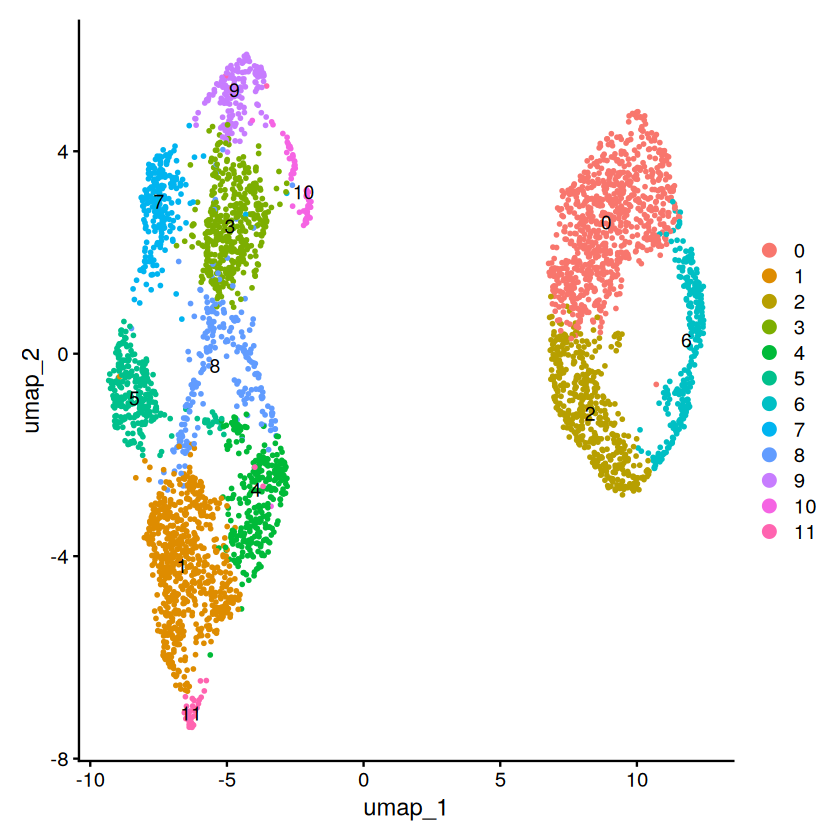

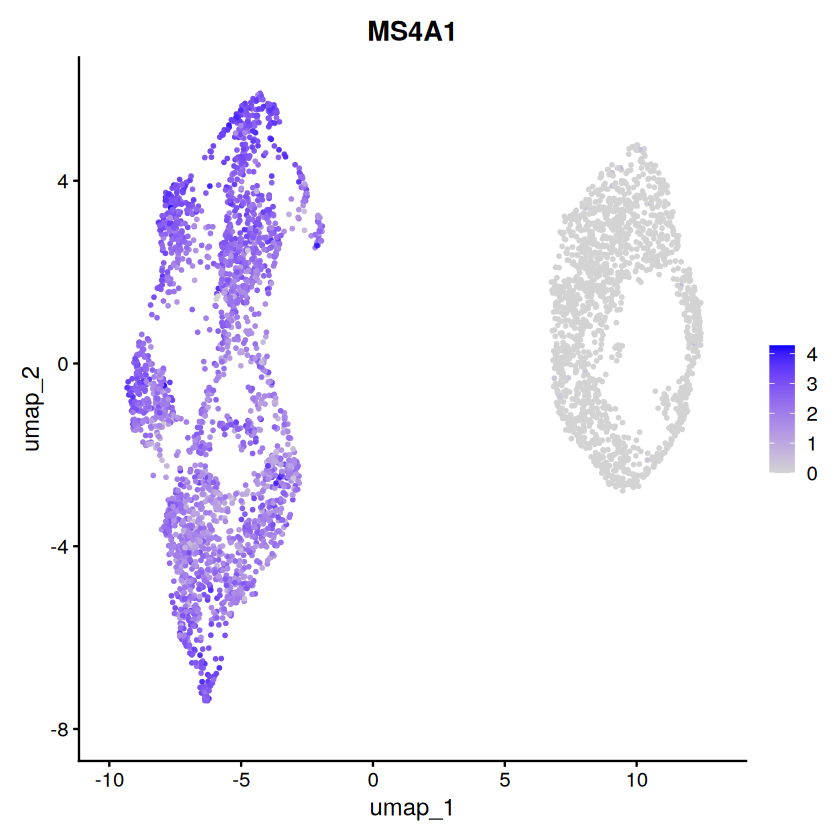

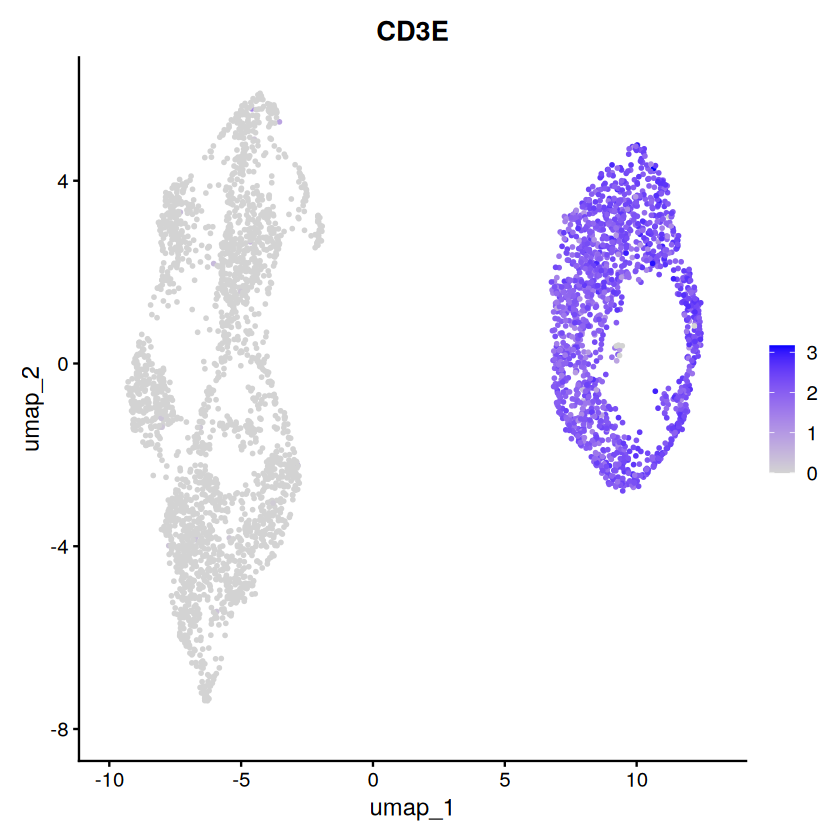

In [6]:
DimPlot(so, label = T)
FeaturePlot(so, features = 'MS4A1')
FeaturePlot(so, features = 'CD3E')

In [7]:
so <- SetIdent(so, value = 'seurat_clusters')
so <- RenameIdents(so, '0' = 'Jurkat',
                       '1' = 'Raji', 
                   '2' = 'Jurkat', 
                   '3' = 'Raji',
                   '4' = 'Raji',
                    '5' = 'Raji',
                    '6' = 'Jurkat',
                    '7' = 'Raji',
                    '8' = 'Raji',
                  '9' = 'Raji',
                  '10' = 'Raji',
                  '11' = 'Raji')
so$celltype <- Idents(so)

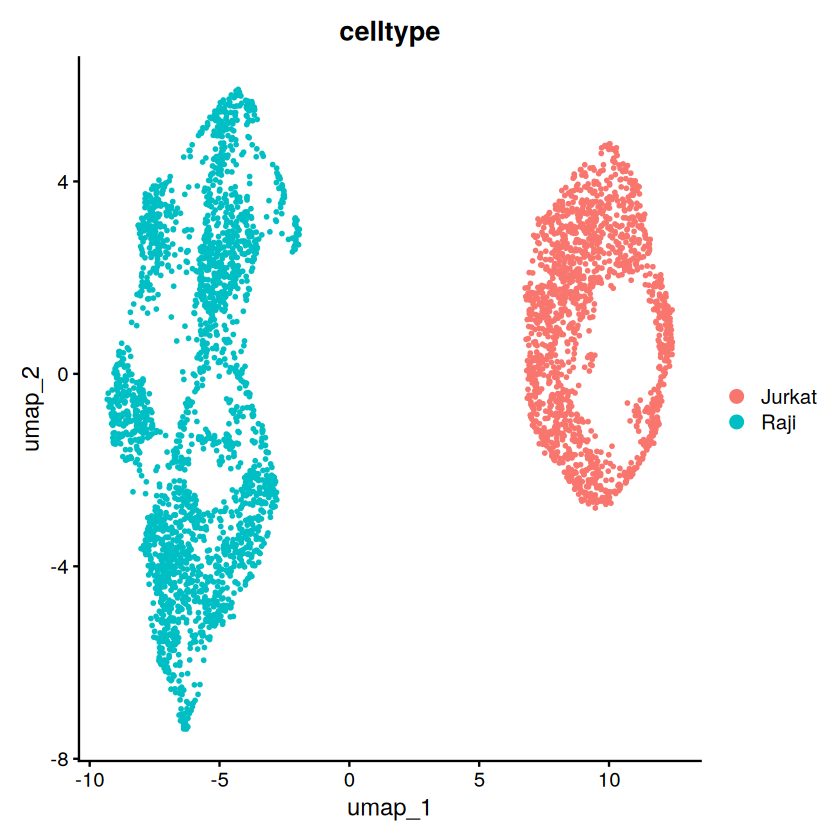

In [8]:
DimPlot(so, group.by = 'celltype')

In [9]:
DefaultAssay(so) <- 'combined_mtx'

In [10]:
# Open the PDF graphics device
pdf("plots/Fig1f_celltype_umap.pdf", width = 8, height = 8) # You can specify width and height in inches

# Create your plot
DimPlot(so, group.by = 'celltype', cols = c('#e36414','#0f4c5c')) + ggtitle('Cell Type')

# Close the graphics device to save the plot
dev.off()

agg_record_1775714380 
                    2

In [11]:
# Open the PDF graphics device
pdf("plots/Fig1f_flex_expression_umaps.pdf", width = 8, height = 16) # You can specify width and height in inches

# Create your plot
p2 <- FeaturePlot(so, features = 'rna_FBXW7', order = T) & scale_color_viridis(option='inferno') & ggtitle('FBXW7 Flex Probe Expression')
p3 <- FeaturePlot(so, features = 'rna_TP53', order = T) & scale_color_viridis(option='inferno') & ggtitle('TP53 Flex Probe Expression')
cowplot::plot_grid(p2,p3,ncol=1)

# Close the graphics device to save the plot
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


agg_record_313611514 
                   2

In [12]:
# Open the PDF graphics device
pdf("plots/Fig1f_custom_transcripts_violins.pdf", width = 16, height = 16) # You can specify width and height in inches

# Create your plot
p4 <- VlnPlot(so, features = 'chr4-152326137', group.by = 'celltype',cols = c('#e36414','#0f4c5c')) & ylim(1,5) & ggtitle('FBXW7 Mutation Expression') & xlab('UMIs')
p4_1 <- VlnPlot(so, features = 'chr4-152326137-WT', group.by = 'celltype',cols = c('#e36414','#0f4c5c')) & ylim(1,5) & ggtitle('FBXW7 Wild Type Expression') & xlab('UMIs')
p6 <- VlnPlot(so, features = 'chr17-7674263', group.by = 'celltype',cols = c('#e36414','#0f4c5c')) & ylim(1,20) & ggtitle('TP53 Mutation Expression') & xlab('UMIs')
p6_1 <- VlnPlot(so, features = 'chr17-7674263-WT', group.by = 'celltype',cols = c('#e36414','#0f4c5c')) & ylim(1,20) & ggtitle('TP53 Wild Type Expression') & xlab('UMIs')
cowplot::plot_grid(p4,p4_1,p6,p6_1,ncol=2)

# Close the graphics device to save the plot
dev.off()

Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“Removed 3819 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 3819 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 3497 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“R

agg_record_147012550 
                   2

In [13]:
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/pythonscrna12/lib/libmkl_rt.so.2;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] future_1.67.0      viridis_0.6.5      viridisLite_0.4.2  ggplot2_4.0.0     
[5] dplyr_1.1.4        Seurat_5.3.0       SeuratObject_5.2.0 sp_2.2-0          
[9] Matrix_1.7-4      

loaded via a namespace (and not attached):
  [1] RColorBrewer_1.1-3     jsonlite_2.0.0         magrittr_2.0.4        
  [4] spatstat.utils_3